# Intraday Liquidity Risk: Payment Flows, Buffers, and Time-to-Breach

## Objective

This notebook documents the **Liquidity Risk** workstream of the 
*Enterprise Risk, Credit Risk, Liquidity Risk, and Fraud Analytics for Canadian Payments* project.

The goal is to:
- Simulate intraday payment inflows and outflows under three scenarios:
  - `base_case`, `stress_volume`, and `severe_stress`
- Track intraday liquidity position and buffer usage over the day
- Compute KRIs such as minimum position, buffer warnings, breaches, and time-to-breach
- Present the results in a way that reflects how a **second-line risk function** would monitor and escalate intraday liquidity risk

## Business Problem

In a payments environment, intraday liquidity risk arises when the **timing of inflows and outflows** causes cash shortfalls during the day, even if the end-of-day balance is adequate.

Key challenges include:

- Meeting payment and settlement obligations **on time** throughout the day.
- Managing timing mismatches between incoming and outgoing payments.
- Ensuring that **intraday liquidity buffers** are sufficient under both normal and stressed conditions.
- Knowing how quickly buffers are being consumed and when **limits or thresholds are breached**.

Supervisory guidance on intraday liquidity emphasizes that institutions should actively manage intraday positions and risks so they can meet payment and settlement obligations in normal and stressed conditions, supported by robust monitoring tools and governance. [web:135][web:127][web:119]

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-darkgrid")

positions_path = Path("../data/processed/intraday_liquidity_positions.csv")
kri_path = Path("../outputs/intraday_liquidity_kri_summary.csv")

positions = pd.read_csv(positions_path, parse_dates=["timestamp"])
kri = pd.read_csv(kri_path)

positions.head()

,timestamp,inflow,outflow,scenario,net_flow,cumulative_net_flow,intraday_position,buffer_available,buffer_usage_pct,warning_flag,breach_flag,time_since_start_min
0,2026-01-05 09:00:00,17675.609629,6.890040e+05,base_case,-6.713283e+05,-6.713283e+05,6.332867e+07,3.332867e+07,0.019745,False,False,0.0
1,2026-01-05 09:15:00,27564.664772,1.030813e+06,base_case,-1.003248e+06,-1.674577e+06,6.232542e+07,3.232542e+07,0.049252,False,False,15.0
2,2026-01-05 09:30:00,52008.754988,1.489590e+06,base_case,-1.437581e+06,-3.112158e+06,6.088784e+07,3.088784e+07,0.091534,False,False,30.0
3,2026-01-05 09:45:00,80914.617658,1.816015e+06,base_case,-1.735100e+06,-4.847258e+06,5.915274e+07,2.915274e+07,0.142566,False,False,45.0
4,2026-01-05 10:00:00,106193.489927,2.254360e+06,base_case,-2.148167e+06,-6.995425e+06,5.700458e+07,2.700458e+07,0.205748,False,False,60.0


In [4]:
kri

,scenario,min_intraday_position,min_buffer_available,warning_intervals,breach_intervals,time_to_first_warning_min,time_to_first_breach_min,status
0,base_case,34079586.10,4079586.1,9,0,135.0,NaN,Amber
1,severe_stress,3872893.75,0.0,26,17,90.0,120.0,Red
2,stress_volume,28182308.48,0.0,12,5,120.0,180.0,Red


### KRI Snapshot Interpretation

From this synthetic example:

- **Base case** shows warning intervals but no buffer exhaustion, with status **Amber**. This suggests the buffer is being used but remains sufficient under normal conditions.
- **Stress volume** has more warning and breach intervals and a later time to first breach, indicating that higher outflows and modest inflow delays can push the buffer into stressed territory.
- **Severe stress** shows earlier and more frequent breaches, with status **Red**, which is consistent with a scenario where intraday funding, payment pacing, or contingency actions would be needed.

This is consistent with how intraday liquidity risk metrics and monitoring tools are used to track how quickly buffers are consumed and when escalation thresholds are reached.

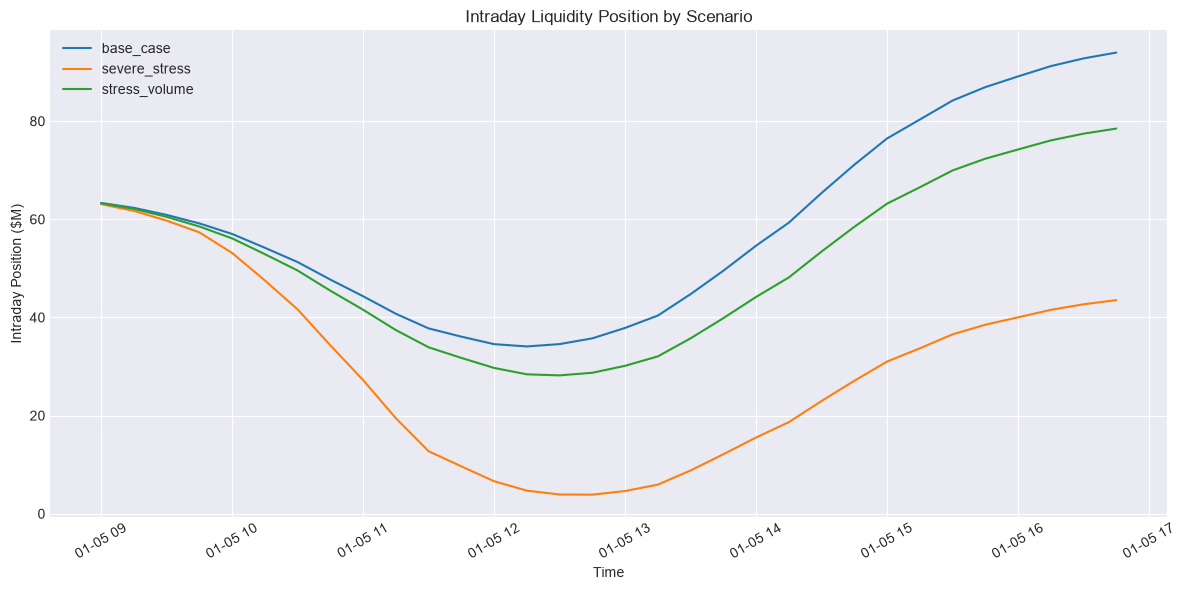

In [5]:
plt.figure(figsize=(12, 6))

for scenario, group in positions.groupby("scenario"):
    plt.plot(
        group["timestamp"],
        group["intraday_position"] / 1_000_000,
        label=scenario,
    )

plt.xlabel("Time")
plt.ylabel("Intraday Position ($M)")
plt.title("Intraday Liquidity Position by Scenario")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

### Intraday Position Interpretation

- All three scenarios start from the same synthetic starting balance.
- In the **base case**, the intraday position dips but remains comfortably above zero.
- In **stress_volume** and **severe_stress**, positions dip much lower, showing how sustained outflows and weaker inflows increase the risk of hitting operational or limit constraints.
- The severe stress curve typically reaches the lowest points and does so earlier, which is directionally aligned with the scenario design.

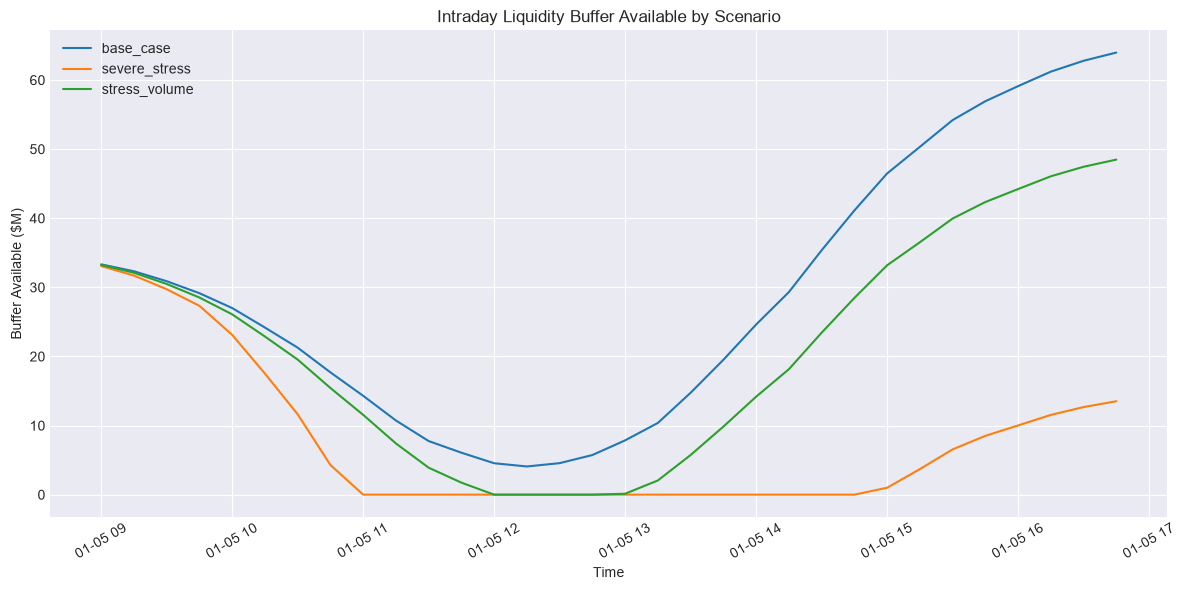

In [6]:
plt.figure(figsize=(12, 6))

for scenario, group in positions.groupby("scenario"):
    plt.plot(
        group["timestamp"],
        group["buffer_available"] / 1_000_000,
        label=scenario,
    )

plt.xlabel("Time")
plt.ylabel("Buffer Available ($M)")
plt.title("Intraday Liquidity Buffer Available by Scenario")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

### Buffer Usage Interpretation

- **Base case**:
  - Buffer usage enters a lower comfort zone at various points (warning intervals),
  - But the buffer does not hit zero, which is consistent with an intraday buffer calibrated for normal operating conditions.

- **Stress volume**:
  - Buffer is used more aggressively, with intervals where it reaches zero or near-zero (breach intervals),
  - This demonstrates how sustained higher payment outflows and modest inflow delays can exhaust the buffer in the second half of the day.

- **Severe stress**:
  - The buffer is exhausted earlier and for longer periods,
  - This scenario represents conditions where intraday funding, payment throttling, or contingency funding actions would be needed to avoid settlement disruption.

This aligns with the idea that intraday liquidity monitoring should track buffer utilization, limit breaches, and time-to-breach to support timely management action.

In [7]:
kri[[
    "scenario",
    "min_intraday_position",
    "min_buffer_available",
    "warning_intervals",
    "breach_intervals",
    "time_to_first_warning_min",
    "time_to_first_breach_min",
    "status",
]]

,scenario,min_intraday_position,min_buffer_available,warning_intervals,breach_intervals,time_to_first_warning_min,time_to_first_breach_min,status
0,base_case,34079586.10,4079586.1,9,0,135.0,NaN,Amber
1,severe_stress,3872893.75,0.0,26,17,90.0,120.0,Red
2,stress_volume,28182308.48,0.0,12,5,120.0,180.0,Red


### KRI Details and Severity

From a second-line perspective:

- **Minimum buffer available** shows how close each scenario comes to exhausting intraday liquidity.
- **Warning intervals** capture how often the buffer drops into a lower comfort zone.
- **Breach intervals** capture how often the buffer is effectively exhausted, triggering a "Red" condition.
- **Time-to-first-warning** and **time-to-first-breach** provide a sense of how quickly stress emerges during the day.

Combined, these KRIs help answer questions such as:

- How much buffer is really needed for normal operations?
- At what point in the day does stress typically manifest?
- Under which scenarios would payment pacing or contingency funding need to be activated?

## Second-Line Interpretation

Viewed through a second-line ERM lens, this intraday analysis supports:

- **Ongoing monitoring:** Track KRIs such as minimum buffer available, number of breach intervals, and time-to-first-breach to understand whether intraday risk is trending toward the limit of risk appetite.
- **Escalation:** Define clear escalation thresholds for Amber and Red scenarios (e.g., number of breaches or how early they occur) and align them with governance expectations.
- **Payment operations coordination:** Use the outputs to inform payment operations when to consider sequencing non-critical payments or working with treasury to source additional intraday funds in stress conditions.
- **Scenario testing:** Demonstrate that intraday buffers and limits remain adequate under a range of scenarios, not only under average conditions.

These steps are aligned with sound practices that call for active management of intraday liquidity positions and risks to meet payment and settlement obligations in both normal times and stress.

## Limitations and Next Steps

**Limitations:**

- The flows, starting balances, and buffers are synthetic and stylised.
- Only one participant perspective is modelled; system-level dynamics and counterparties are not included.
- No explicit credit lines or central bank intraday facilities are modelled.

**Next Steps:**

- Extend the simulation to multiple participants or counterparties.
- Introduce more specific stress narratives (e.g., delayed inbound from a major participant, operational incident).
- Add additional KPIs such as peak intraday usage of available credit lines or maximum net debit position.
- Integrate this intraday module into the final ERM dashboard alongside credit risk and fraud metrics.